# **1. Perkenalan Dataset**


# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **3. Data Wrangling**

## Data loading

In [2]:
# dwonload dataset
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

In [3]:
# show dataset
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


## Data assesing

In [4]:
# cek info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

Insight singkat dari dataset tersebut:

* Dataset berisi **2.537 transaksi keuangan** dengan kombinasi data **numerik (5 fitur)** dan **kategorikal (11 fitur)** → cocok untuk analisis perilaku transaksi.
* Ada **missing values di hampir semua kolom** (sekitar 20–30 data hilang per kolom) → perlu cleaning sebelum modeling.
* Fitur penting terbagi jadi:

  * **Perilaku transaksi**: `TransactionAmount`, `TransactionDuration`, `TransactionType`
  * **Keamanan**: `LoginAttempts`, `IP Address`, `DeviceID`
  * **Profil user**: `CustomerAge`, `CustomerOccupation`, `AccountBalance`
  * **Konteks waktu & lokasi**: `TransactionDate`, `PreviousTransactionDate`, `Location`, `Channel`
* Dataset ini **sangat kuat untuk fraud detection / anomaly detection**, karena ada kombinasi:

  * pola transaksi
  * aktivitas login
  * identitas device & lokasi

**Intinya:** dataset ini memungkinkan kamu mendeteksi transaksi mencurigakan berdasarkan **perilaku, waktu, dan identitas pengguna**.


In [5]:
# cek missing value
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [6]:
#  cek duplikasi data
print('Duplilasi data ada: ', df.duplicated().sum())

Duplilasi data ada:  21


In [7]:
# cek analisa deskriptif
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


## Data cleaning

### Handle missing value

In [8]:
# Handle missing value

# =========================
# COPY DATASET
# =========================
df_clean = df.copy()

# =========================
# 1. HANDLE MISSING - KOLOM IDENTITAS
# =========================
# Kolom: TransactionID (PENTING → wajib ada)
df_clean = df_clean.dropna(subset=['TransactionID'])

# Kolom identitas lainnya → isi 'Unknown'
id_cols = ['AccountID', 'DeviceID', 'MerchantID', 'IP Address']

for col in id_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("\nMissing setelah handle ID:")
print(df_clean[id_cols + ['TransactionID']].isnull().sum())


# =========================
# 2. HANDLE MISSING - KOLOM NUMERIK
# =========================
# Kolom numerik → isi dengan median
num_cols = [
    'TransactionAmount',
    'CustomerAge',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance'
]

for col in num_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("\nMissing setelah handle numerik:")
print(df_clean[num_cols].isnull().sum())


# =========================
# 3. HANDLE MISSING - KOLOM KATEGORIKAL
# =========================
# Kolom kategorikal → isi 'Unknown' + rapikan format
cat_cols = [
    'TransactionType',
    'Location',
    'Channel',
    'CustomerOccupation'
]

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')
    df_clean[col] = df_clean[col].str.lower().str.strip()

print("\nMissing setelah handle kategorikal:")
print(df_clean[cat_cols].isnull().sum())


# =========================
# 4. HANDLE MISSING - KOLOM TANGGAL
# =========================
date_cols = ['TransactionDate', 'PreviousTransactionDate']

# Urutkan dulu biar ffill masuk akal
df_clean = df_clean.sort_values('TransactionDate')

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
    df_clean[col] = df_clean[col].fillna(method='ffill')

print("\nMissing setelah handle tanggal:")
print(df_clean[date_cols].isnull().sum())


# =========================
# 5. TAMBAHAN (OPSIONAL) - FLAG MISSING
# =========================
# Menandai data yang awalnya missing (penting untuk fraud detection)
# for col in df.columns:
#     df_clean[col + '_missing'] = df[col].isnull().astype(int)


# =========================
# 6. CEK AKHIR
# =========================
print("\nTotal missing setelah cleaning:")
print(df_clean.isnull().sum())


Missing setelah handle ID:
AccountID        0
DeviceID         0
MerchantID       0
IP Address       0
TransactionID    0
dtype: int64

Missing setelah handle numerik:
TransactionAmount      0
CustomerAge            0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

Missing setelah handle kategorikal:
TransactionType       0
Location              0
Channel               0
CustomerOccupation    0
dtype: int64

Missing setelah handle tanggal:
TransactionDate            0
PreviousTransactionDate    0
dtype: int64

Total missing setelah cleaning:
TransactionID              0
AccountID                  0
TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
Acco

/tmp/ipykernel_1550/3158150685.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method='ffill')
/tmp/ipykernel_1550/3158150685.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method='ffill')


In [9]:
# cek data
df_clean.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
35,TX000036,AC00267,124.76,2023-10-16 16:32:56,debit,seattle,D000042,59.145.242.13,M002,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23
469,TX000470,AC00036,71.95,2023-02-13 16:39:52,credit,unknown,D000410,162.58.247.55,M100,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23
2044,TX002045,AC00241,188.61,2024-01-01 17:16:23,debit,boston,D000451,107.248.120.12,M083,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23
2530,TX002108,AC00190,46.60,2023-08-30 17:54:55,debit,detroit,D000029,147.227.81.224,M060,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23
2423,TX002424,AC00340,332.06,2023-06-21 16:38:54,debit,seattle,D000365,94.37.250.128,M086,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23


In [10]:
df_clean.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


### Handle duplaced data

In [11]:
# Menghapus data duplikat.

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df_clean.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df_clean.duplicated().sum()

np.int64(0)

# **4. Exploratory Data Analysis (EDA)**


In [12]:
# data final untuk EDA
df_clean.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
35,TX000036,AC00267,124.76,2023-10-16 16:32:56,debit,seattle,D000042,59.145.242.13,M002,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23
469,TX000470,AC00036,71.95,2023-02-13 16:39:52,credit,unknown,D000410,162.58.247.55,M100,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23
2044,TX002045,AC00241,188.61,2024-01-01 17:16:23,debit,boston,D000451,107.248.120.12,M083,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23
2530,TX002108,AC00190,46.60,2023-08-30 17:54:55,debit,detroit,D000029,147.227.81.224,M060,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23
2423,TX002424,AC00340,332.06,2023-06-21 16:38:54,debit,seattle,D000365,94.37.250.128,M086,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23


In [13]:
# data deskriptif
df_clean.describe()

,TransactionAmount,PreviousTransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,2486.000000,2486,2486.000000,2486.000000,2486.000000,2486.000000,2486
mean,296.251879,2023-07-05 21:49:01.639179264,44.632341,119.393403,1.121883,5111.522868,2024-11-04 08:09:24.184231680
min,0.260000,2023-01-02 16:00:06,18.000000,10.000000,1.000000,101.250000,2024-11-04 08:06:23
25%,83.180000,2023-04-03 16:06:05.750000128,27.000000,63.000000,1.000000,1519.357500,2024-11-04 08:07:55
50%,211.695000,2023-07-07 18:01:06,45.000000,112.000000,1.000000,4732.810000,2024-11-04 08:09:24
75%,409.347500,2023-10-06 18:55:28.750000128,59.000000,161.000000,1.000000,7643.307500,2024-11-04 08:10:56
max,1831.020000,2024-01-01 18:21:50,80.000000,300.000000,5.000000,14977.990000,2024-11-04 08:12:23
std,288.764636,NaN,17.726198,69.554626,0.595107,3876.575174,NaN


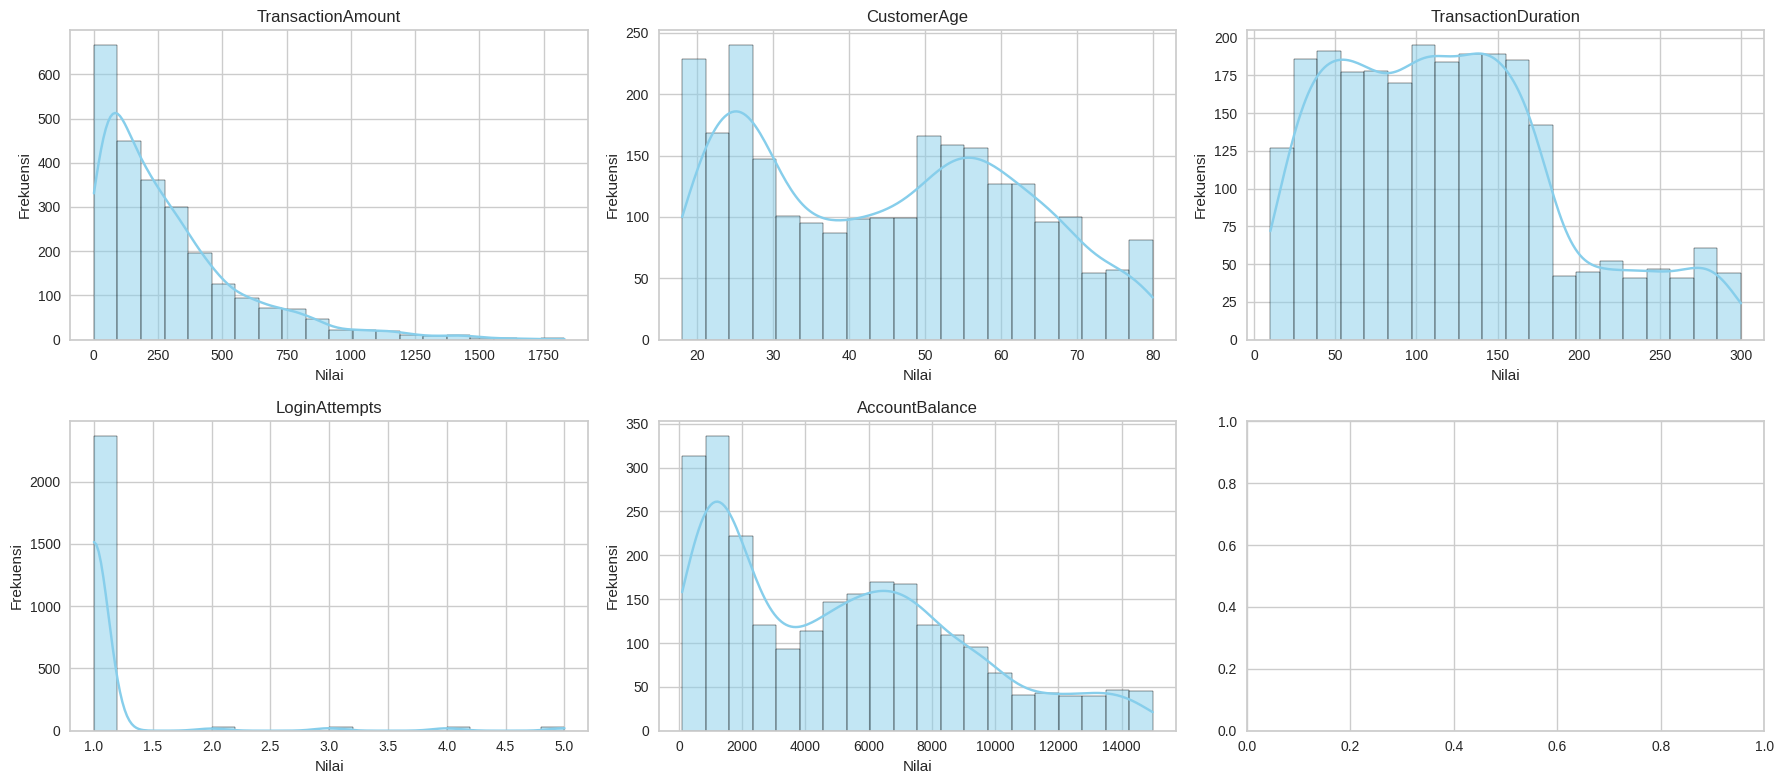

In [14]:
# Menampilkan histogram untuk semua kolom numerik

# Memilih kolom numerik
numerical_cols = df_clean.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df_clean[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

plt.tight_layout()
plt.show()

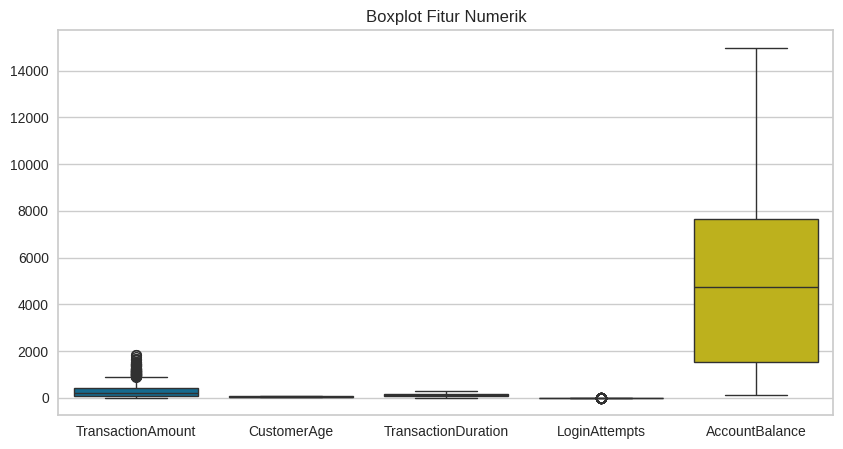

In [15]:
# BOXPLOT (Deteksi Outlier)
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[numerical_cols])
plt.title("Boxplot Fitur Numerik")
plt.show()

**Insight**

Berdasarkan boxplot fitur numerik, ditemukan bahwa variabel TransactionAmount memiliki banyak outlier yang menunjukkan adanya transaksi dengan nilai ekstrem. Selain itu, AccountBalance memiliki rentang nilai yang sangat luas dibandingkan fitur lainnya, sehingga berpotensi mendominasi proses clustering. Oleh karena itu, diperlukan proses normalisasi untuk menyamakan skala antar fitur.

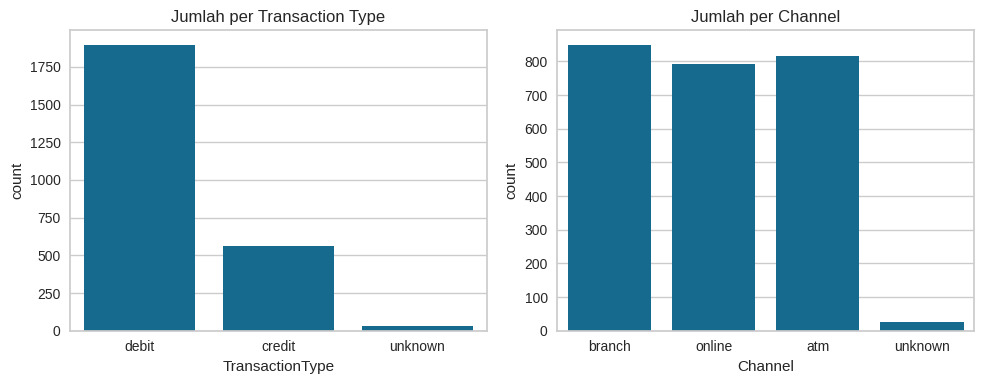

In [16]:
# COUNTPLOT (Kategori)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x='TransactionType', data=df_clean)
plt.title("Jumlah per Transaction Type")

plt.subplot(1,2,2)
sns.countplot(x='Channel', data=df_clean)
plt.title("Jumlah per Channel")

plt.tight_layout()
plt.show()

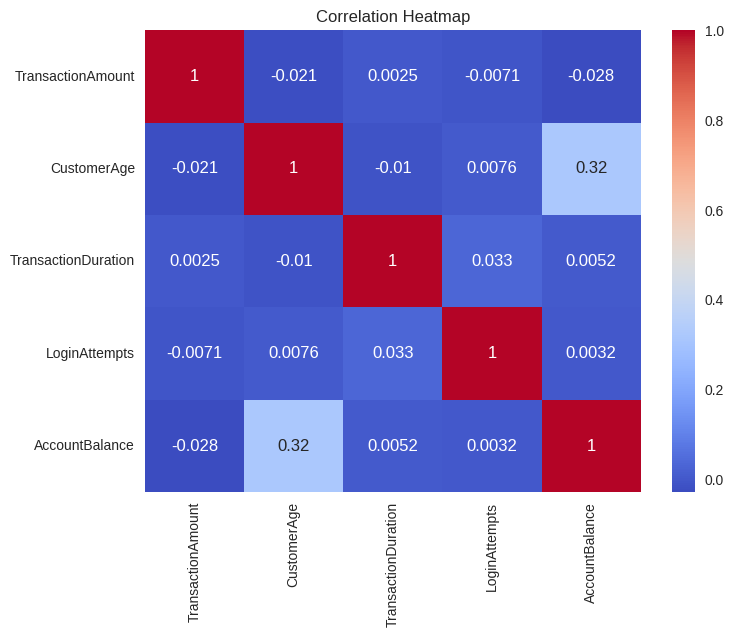

In [17]:
# HEATMAP (Korelasi)

plt.figure(figsize=(8,6))

corr = df_clean[[
    'TransactionAmount',
    'CustomerAge',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance'
]].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **5. Data Preprocessing**

## Encode data

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2486 entries, 35 to 2299
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2486 non-null   object        
 1   AccountID                2486 non-null   object        
 2   TransactionAmount        2486 non-null   float64       
 3   PreviousTransactionDate  2486 non-null   datetime64[ns]
 4   TransactionType          2486 non-null   object        
 5   Location                 2486 non-null   object        
 6   DeviceID                 2486 non-null   object        
 7   IP Address               2486 non-null   object        
 8   MerchantID               2486 non-null   object        
 9   Channel                  2486 non-null   object        
 10  CustomerAge              2486 non-null   float64       
 11  CustomerOccupation       2486 non-null   object        
 12  TransactionDuration      2486 non-null

In [19]:
df_clean.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
35,TX000036,AC00267,124.76,2023-10-16 16:32:56,debit,seattle,D000042,59.145.242.13,M002,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23
469,TX000470,AC00036,71.95,2023-02-13 16:39:52,credit,unknown,D000410,162.58.247.55,M100,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23
2044,TX002045,AC00241,188.61,2024-01-01 17:16:23,debit,boston,D000451,107.248.120.12,M083,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23
2530,TX002108,AC00190,46.60,2023-08-30 17:54:55,debit,detroit,D000029,147.227.81.224,M060,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23
2423,TX002424,AC00340,332.06,2023-06-21 16:38:54,debit,seattle,D000365,94.37.250.128,M086,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23


In [20]:
# Hapus kolom yang tidak diperlukan

df_encode = df_clean.copy()

df_encode = df_encode.drop(columns=[
    'TransactionID',
    'AccountID',
    'DeviceID',
    'IP Address',
    'MerchantID'
])

df_encode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2486 entries, 35 to 2299
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionAmount        2486 non-null   float64       
 1   PreviousTransactionDate  2486 non-null   datetime64[ns]
 2   TransactionType          2486 non-null   object        
 3   Location                 2486 non-null   object        
 4   Channel                  2486 non-null   object        
 5   CustomerAge              2486 non-null   float64       
 6   CustomerOccupation       2486 non-null   object        
 7   TransactionDuration      2486 non-null   float64       
 8   LoginAttempts            2486 non-null   float64       
 9   AccountBalance           2486 non-null   float64       
 10  TransactionDate          2486 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(5), object(4)
memory usage: 233.1+ KB


In [21]:
df_encode.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
35,124.76,2023-10-16 16:32:56,debit,seattle,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23
469,71.95,2023-02-13 16:39:52,credit,unknown,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23
2044,188.61,2024-01-01 17:16:23,debit,boston,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23
2530,46.60,2023-08-30 17:54:55,debit,detroit,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23
2423,332.06,2023-06-21 16:38:54,debit,seattle,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23


In [22]:
for col in cat_cols:
    print(col, df_encode[col].nunique())

TransactionType 3
Location 44
Channel 4
CustomerOccupation 5


In [23]:
# Lanjut One Hot Encoding

cat_cols = ['TransactionType', 'Channel', 'CustomerOccupation']

cols_exist = [col for col in cat_cols if col in df_encode.columns]

df_encode = pd.get_dummies(
    df_encode,
    columns=cols_exist,
    drop_first=True,
    dtype=int
)

df_encode.head()

,TransactionAmount,PreviousTransactionDate,Location,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionType_debit,TransactionType_unknown,Channel_branch,Channel_online,Channel_unknown,CustomerOccupation_engineer,CustomerOccupation_retired,CustomerOccupation_student,CustomerOccupation_unknown
35,124.76,2023-10-16 16:32:56,seattle,49.0,45.0,1.0,5764.72,2024-11-04 08:06:23,1,0,1,0,0,1,0,0,0
469,71.95,2023-02-13 16:39:52,unknown,59.0,53.0,1.0,9267.32,2024-11-04 08:06:23,0,0,0,1,0,1,0,0,0
2044,188.61,2024-01-01 17:16:23,boston,67.0,26.0,1.0,7167.57,2024-11-04 08:06:23,1,0,0,1,0,0,1,0,0
2530,46.60,2023-08-30 17:54:55,detroit,55.0,68.0,1.0,1562.90,2024-11-04 08:06:23,1,0,0,1,0,0,0,0,0
2423,332.06,2023-06-21 16:38:54,seattle,29.0,221.0,1.0,11826.52,2024-11-04 08:06:23,1,0,0,0,0,0,0,0,0


In [24]:
# cek dataset
df_model = df_encode.copy()
df_model.head()

,TransactionAmount,PreviousTransactionDate,Location,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionType_debit,TransactionType_unknown,Channel_branch,Channel_online,Channel_unknown,CustomerOccupation_engineer,CustomerOccupation_retired,CustomerOccupation_student,CustomerOccupation_unknown
35,124.76,2023-10-16 16:32:56,seattle,49.0,45.0,1.0,5764.72,2024-11-04 08:06:23,1,0,1,0,0,1,0,0,0
469,71.95,2023-02-13 16:39:52,unknown,59.0,53.0,1.0,9267.32,2024-11-04 08:06:23,0,0,0,1,0,1,0,0,0
2044,188.61,2024-01-01 17:16:23,boston,67.0,26.0,1.0,7167.57,2024-11-04 08:06:23,1,0,0,1,0,0,1,0,0
2530,46.60,2023-08-30 17:54:55,detroit,55.0,68.0,1.0,1562.90,2024-11-04 08:06:23,1,0,0,1,0,0,0,0,0
2423,332.06,2023-06-21 16:38:54,seattle,29.0,221.0,1.0,11826.52,2024-11-04 08:06:23,1,0,0,0,0,0,0,0,0


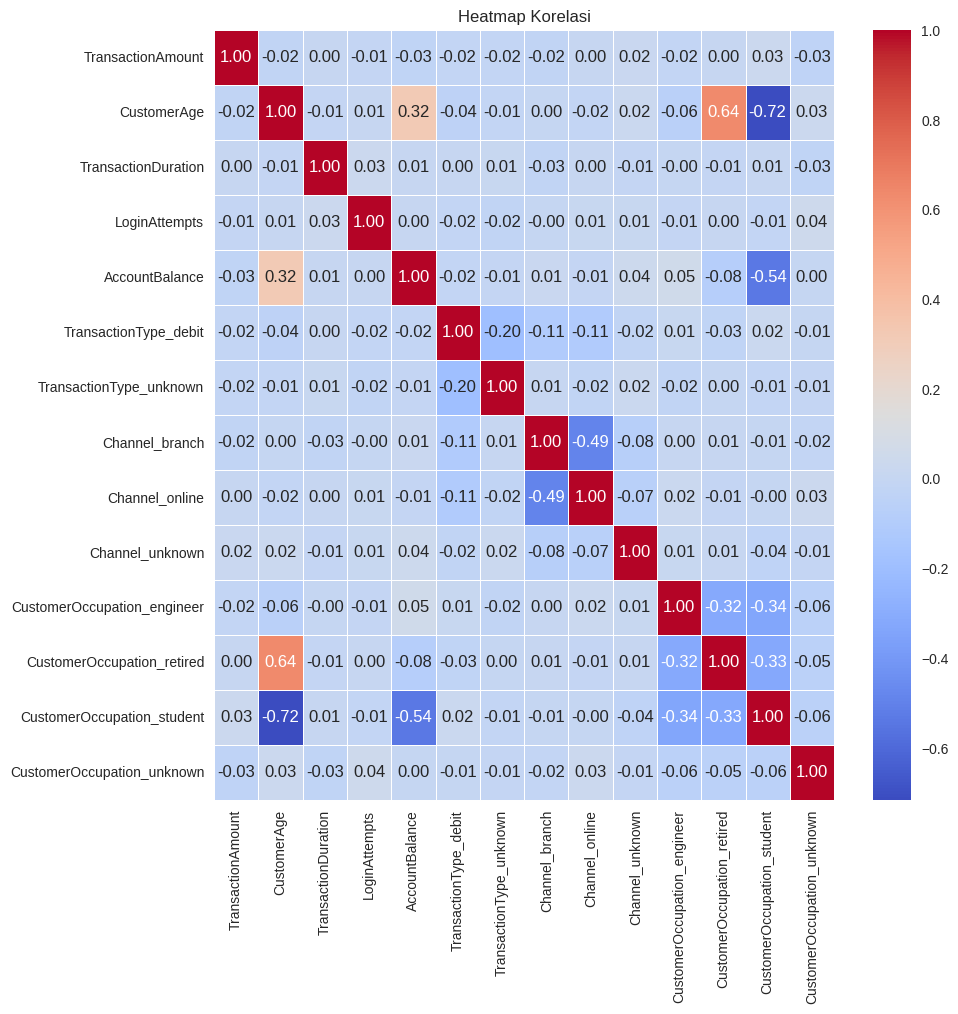

In [25]:
# plot matrik korelasi
num_features = df_model.select_dtypes(include=[np.number])
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(10, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

## Tangani outlier

In [26]:
# cek outlier

numeric_columns = df_model.select_dtypes(include=['number']).columns

outlier_summary = []

for col in numeric_columns:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_model[(df_model[col] < lower_bound) | (df_model[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Jumlah Outlier': len(outliers),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

                        Feature  Jumlah Outlier  Lower Bound  Upper Bound
0             TransactionAmount             109   -406.07125    898.59875
1                   CustomerAge               0    -21.00000    107.00000
2           TransactionDuration               0    -84.00000    308.00000
3                 LoginAttempts             119      1.00000      1.00000
4                AccountBalance               0  -7666.56750  16829.23250
5         TransactionType_debit             589      1.00000      1.00000
6       TransactionType_unknown              30      0.00000      0.00000
7                Channel_branch               0     -1.50000      2.50000
8                Channel_online               0     -1.50000      2.50000
9               Channel_unknown              27      0.00000      0.00000
10  CustomerOccupation_engineer             618      0.00000      0.00000
11   CustomerOccupation_retired             579      0.00000      0.00000
12   CustomerOccupation_student       

**Insight**

Berdasarkan deteksi outlier menggunakan metode IQR, analisis difokuskan pada fitur numerik kontinu seperti TransactionAmount dan LoginAttempts. Fitur hasil encoding kategorikal tidak dianalisis sebagai outlier karena bersifat biner. Ditemukan bahwa TransactionAmount memiliki jumlah outlier yang signifikan sehingga dilakukan teknik capping (winsorizing) untuk membatasi nilai ekstrem tanpa menghilangkan data. Sementara itu, fitur LoginAttempts memiliki variasi yang sangat rendah sehingga pengaruhnya terhadap model clustering relatif kecil.

In [27]:
# Tangani outlier
numeric_cols = ['TransactionAmount']

for col in numeric_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_model.loc[:, col] = df_model[col].clip(lower, upper)

    print(f"{col} done | batas: ({lower:.2f}, {upper:.2f})")

TransactionAmount done | batas: (-406.07, 898.60)


In [28]:
# cek hasil
for col in numeric_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    print(f"{col}: {count} outlier tersisa")

TransactionAmount: 0 outlier tersisa


## Standarisasi data

In [29]:
# Standarisasi

from sklearn.preprocessing import StandardScaler

# pilih fitur (pastikan sudah didefinisikan sebelumnya)
features = [
    'TransactionAmount',
    'CustomerAge',
    'TransactionDuration',
    'AccountBalance'
]

# scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model[features])

# ubah ke dataframe
data_scaled = pd.DataFrame(
    scaled_data,
    columns=features,
    index=df_model.index
)

# cek hasil
data_scaled.describe()

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
count,2.486000e+03,2.486000e+03,2.486000e+03,2.486000e+03
mean,-3.715630e-17,-1.314761e-16,2.215087e-17,-5.573445e-17
std,1.000201e+00,1.000201e+00,1.000201e+00,1.000201e+00
min,-1.137542e+00,-1.502731e+00,-1.573086e+00,-1.292708e+00
25%,-8.044140e-01,-9.949053e-01,-8.109417e-01,-9.268202e-01
50%,-2.881092e-01,2.074516e-02,-1.063177e-01,-9.771230e-02
75%,5.059532e-01,8.106955e-01,5.983063e-01,6.532297e-01
max,2.471504e+00,1.995621e+00,2.597138e+00,2.545663e+00


**Insight**

Dalam proses clustering, tidak semua fitur hasil *One Hot Encoding* digunakan pada tahap pelatihan model. Fitur yang dipilih hanya terdiri dari fitur numerik kontinu, yaitu *TransactionAmount*, *CustomerAge*, *TransactionDuration*, dan *AccountBalance*. Pemilihan fitur ini dilakukan karena algoritma K-Means bekerja berdasarkan perhitungan jarak (*distance-based algorithm*), sehingga lebih efektif digunakan pada data numerik yang memiliki variasi kontinu.

Sementara itu, fitur hasil *One Hot Encoding* seperti *TransactionType*, *Channel*, dan *CustomerOccupation* menghasilkan data biner bernilai 0 dan 1. Penggunaan terlalu banyak fitur biner dapat meningkatkan dimensi data dan menyebabkan terjadinya *curse of dimensionality*, yaitu kondisi ketika jarak antar data menjadi kurang representatif. Akibatnya, proses pembentukan cluster menjadi kurang optimal dan menghasilkan overlap antar cluster.

Selain itu, beberapa fitur kategorikal memiliki jumlah kategori yang cukup banyak, seperti *Location*, sehingga setelah dilakukan *One Hot Encoding* akan menghasilkan banyak kolom tambahan. Hal ini dapat menyebabkan fitur kategorikal mendominasi perhitungan jarak pada algoritma K-Means dan menurunkan kualitas clustering.

Oleh karena itu, penelitian ini memfokuskan proses clustering pada fitur numerik yang dianggap lebih relevan dalam merepresentasikan pola transaksi pengguna. Pendekatan tersebut menghasilkan performa clustering yang lebih stabil dibandingkan penggunaan seluruh fitur hasil encoding.


# **6. Pembangunan Model Clustering**

## Feature selection

In [30]:
from sklearn.decomposition import PCA

# copy data
scaled_df = data_scaled.copy()

# ambil data numerik
df_numerik = scaled_df.select_dtypes(include=['number']).columns

# Membuat objek PCA
pca = PCA(n_components=4)

# Terapkan PCA hanya pada data numerik
X_pca = pca.fit_transform(scaled_df[df_numerik])

# Menampilkan total variansi yang dijelaskan
total_variance = sum(pca.explained_variance_ratio_)
print(f"Total Variansi yang Dijelaskan oleh Komponen Utama: {total_variance}")

Total Variansi yang Dijelaskan oleh Komponen Utama: 1.0


## Modeling Kmeans

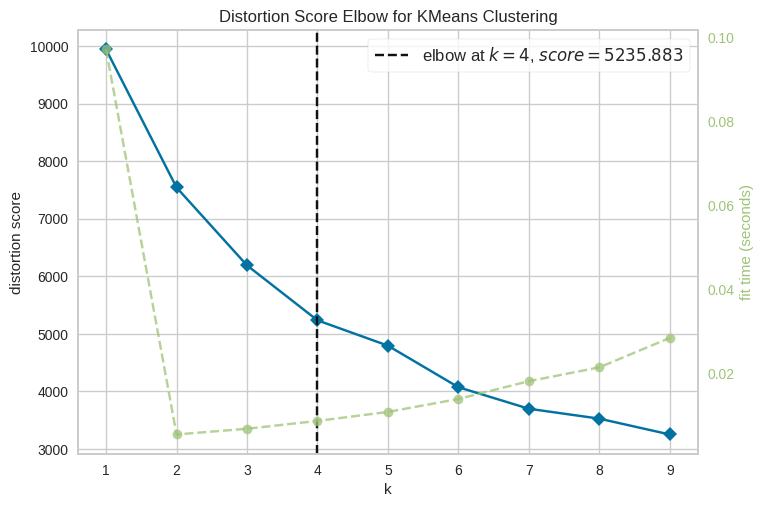

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()

# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10))

# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X_pca)

# Menampilkan grafik elbow untuk analisis
visualizer.show()

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Evaluasi Silhouette Score untuk beberapa k:")
for k in range(2,6):
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_test.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k={k}, silhouette={score:.4f}")

Evaluasi Silhouette Score untuk beberapa k:
k=2, silhouette=0.2405
k=3, silhouette=0.2478
k=4, silhouette=0.2410
k=5, silhouette=0.2557


In [33]:
# Training Versi tanpa PCA
from sklearn.cluster import KMeans

# KMeans tanpa PCA
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=20,
    max_iter=600,
    random_state=42
)

clusters_kmens = kmeans.fit_predict(scaled_df)

# simpan hasil
scaled_df['cluster'] = clusters_kmens

In [34]:
# Evaluasi model tanpa PCA
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df.drop(columns=['cluster']), clusters_kmens)
print("Silhouette Score:", score)

Silhouette Score: 0.25597579651440083


In [35]:
# training dengan PCA
from sklearn.cluster import KMeans

# Terapkan K-Means clustering
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=20,
    max_iter=600,
    random_state=42
)

clusters_kmens = kmeans.fit_predict(X_pca)

# Menambahkan hasil clustering ke dataframe
scaled_df['cluster'] = clusters_kmens

In [36]:
# Evaluasi model dengan silhoutte scorr dengan PCA
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_pca, clusters_kmens)
print(f"Silhouette Score Kmens: {silhouette_avg:.4f}")

Silhouette Score Kmens: 0.2560


In [37]:
scaled_df.head()

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance,cluster
35,-0.637368,0.246445,-1.069783,0.168532,4
469,-0.849530,0.810696,-0.954743,1.072244,1
2044,-0.380852,1.262096,-1.343005,0.530484,4
2530,-0.951373,0.584995,-0.739041,-0.915586,4
2423,0.195453,-0.882055,1.461111,1.732547,2


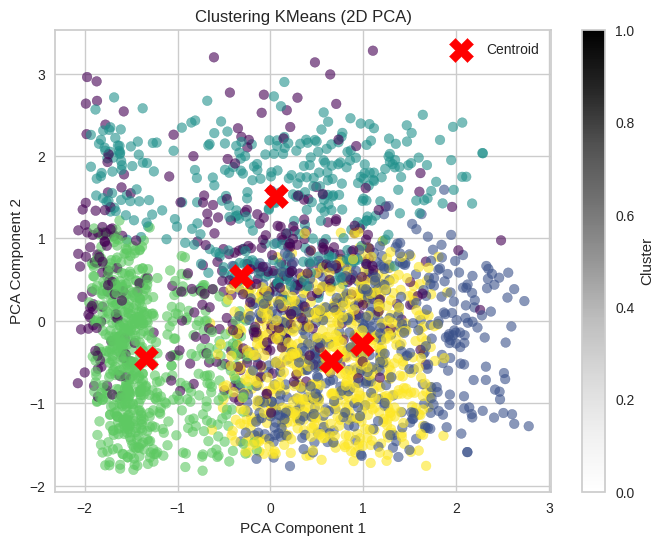

In [38]:
# Visualisasi 2D
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot data
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_kmens,
    cmap='viridis',
    alpha=0.6
)

# Ambil centroid
centroids = kmeans.cluster_centers_

# Plot centroid
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clustering KMeans (2D PCA)')
plt.legend()
plt.colorbar(label='Cluster')
plt.show()

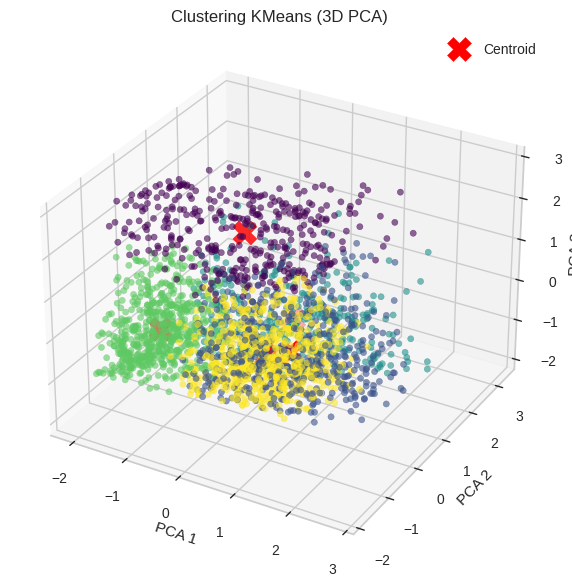

In [39]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=clusters_kmens,
    cmap='viridis',
    alpha=0.6
)

# Ambil centroid
centroids = kmeans.cluster_centers_

# Plot centroid
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    s=300,
    c='red',
    marker='X',
    label='Centroid'
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('Clustering KMeans (3D PCA)')
ax.legend()

plt.show()

**Insight**

Berdasarkan hasil evaluasi menggunakan algoritma K-Means, diperoleh nilai *silhouette score* sebesar 0.25. Nilai ini menunjukkan bahwa kualitas pemisahan antar cluster masih tergolong lemah, sehingga data memiliki tingkat overlap yang cukup tinggi antar kelompok. Hal tersebut mengindikasikan bahwa dataset transaksi tidak memiliki struktur cluster yang benar-benar jelas.

Pada penelitian ini digunakan 4 fitur numerik, yaitu *TransactionAmount*, *CustomerAge*, *TransactionDuration*, dan *AccountBalance*. Keempat fitur tersebut memiliki karakteristik data kontinu dengan rentang nilai yang saling beririsan, sehingga proses pembentukan cluster menjadi lebih sulit dilakukan secara tegas.

Pemilihan jumlah cluster dilakukan dengan beberapa percobaan nilai *k*, dan hasil terbaik diperoleh pada jumlah cluster tertentu meskipun nilai silhouette masih relatif rendah. Kondisi ini menunjukkan bahwa penambahan jumlah cluster tidak selalu meningkatkan kualitas pemisahan data. Jika jumlah cluster terlalu sedikit, data yang memiliki karakteristik berbeda akan tergabung dalam satu kelompok. Sebaliknya, jika jumlah cluster terlalu banyak, maka cluster menjadi terlalu spesifik dan menyebabkan overlap antar cluster semakin tinggi.

Hasil clustering menunjukkan bahwa setiap cluster masih memiliki variasi karakteristik yang cukup besar. Sebagai contoh, terdapat anggota cluster dengan nilai *CustomerAge* yang berbeda jauh tetapi tetap berada pada cluster yang sama. Hal ini menunjukkan bahwa batas antar kelompok tidak terbentuk secara alami pada dataset.

Dengan demikian, hasil clustering dengan silhouette score sebesar 0.25 masih dapat digunakan untuk melihat pola umum transaksi pengguna, namun belum mampu menghasilkan segmentasi yang benar-benar terpisah dengan kuat. Kondisi tersebut sesuai dengan karakteristik data transaksi yang cenderung homogen dan memiliki distribusi fitur yang saling tumpang tindih.


## Modeling DBScan

In [40]:
# training dengan PCA menggunakan DBSCAN
from sklearn.cluster import DBSCAN

# Terapkan DBSCAN
dbscan = DBSCAN(
    eps=1.0,
    min_samples=4
)

clusters_dbscan = dbscan.fit_predict(X_pca)

# copy data
df_dbscan = data_scaled.copy()

# simpan hasil cluster
df_dbscan['cluster'] = clusters_dbscan

from sklearn.metrics import silhouette_score

# evaluasi silhouette score
score = silhouette_score(X_pca, clusters_dbscan)

print("Silhouette Score DBSCAN:", score)

Silhouette Score DBSCAN: 0.3704409758538423


In [41]:
print(set(clusters_dbscan))

{np.int64(0), np.int64(-1)}


In [42]:
import pandas as pd

print(pd.Series(clusters_dbscan).value_counts())

 0    2484
-1       2
Name: count, dtype: int64


In [43]:
# training tanpa PCA menggunakan DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Terapkan DBSCAN
dbscan = DBSCAN(
    eps=1.0,
    min_samples=4
)

clusters_dbscan = dbscan.fit_predict(data_scaled)

# copy data
df_dbscan = data_scaled.copy()

# simpan hasil cluster
df_dbscan['cluster'] = clusters_dbscan

# evaluasi silhouette score
score = silhouette_score(data_scaled, clusters_dbscan)

print("Silhouette Score DBSCAN:", score)

Silhouette Score DBSCAN: 0.37044097585384284


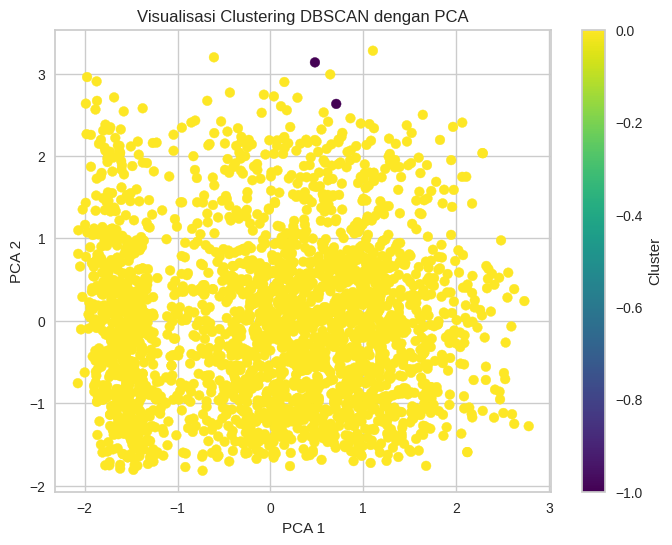

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA untuk visualisasi 2 dimensi
pca = PCA(n_components=4)
X_pca = pca.fit_transform(data_scaled)

# visualisasi cluster DBSCAN
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_dbscan,
    cmap='viridis'
)

plt.title('Visualisasi Clustering DBSCAN dengan PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

**Insight**

Hasil clustering menggunakan DBSCAN menghasilkan silhouette score sebesar 0.37. Namun, sebagian besar data tergabung ke dalam satu cluster utama dengan hanya sedikit data yang terdeteksi sebagai noise. Hal ini menunjukkan bahwa dataset tidak memiliki pemisahan cluster yang kuat meskipun nilai silhouette score relatif lebih tinggi dibandingkan K-Means.

# **7. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [45]:
df_clean['cluster'] = clusters_kmens
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2486 entries, 35 to 2299
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2486 non-null   object        
 1   AccountID                2486 non-null   object        
 2   TransactionAmount        2486 non-null   float64       
 3   PreviousTransactionDate  2486 non-null   datetime64[ns]
 4   TransactionType          2486 non-null   object        
 5   Location                 2486 non-null   object        
 6   DeviceID                 2486 non-null   object        
 7   IP Address               2486 non-null   object        
 8   MerchantID               2486 non-null   object        
 9   Channel                  2486 non-null   object        
 10  CustomerAge              2486 non-null   float64       
 11  CustomerOccupation       2486 non-null   object        
 12  TransactionDuration      2486 non-null

In [46]:
df_clean.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,cluster
35,TX000036,AC00267,124.76,2023-10-16 16:32:56,debit,seattle,D000042,59.145.242.13,M002,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23,4
469,TX000470,AC00036,71.95,2023-02-13 16:39:52,credit,unknown,D000410,162.58.247.55,M100,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23,1
2044,TX002045,AC00241,188.61,2024-01-01 17:16:23,debit,boston,D000451,107.248.120.12,M083,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23,4
2530,TX002108,AC00190,46.60,2023-08-30 17:54:55,debit,detroit,D000029,147.227.81.224,M060,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23,4
2423,TX002424,AC00340,332.06,2023-06-21 16:38:54,debit,seattle,D000365,94.37.250.128,M086,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23,2


In [48]:
# simpan dataframe ke CSV
df_clean.to_csv('Data_hasil_clustering_kmeans.csv', index=False)

print("File berhasil disimpan!")

File berhasil disimpan!


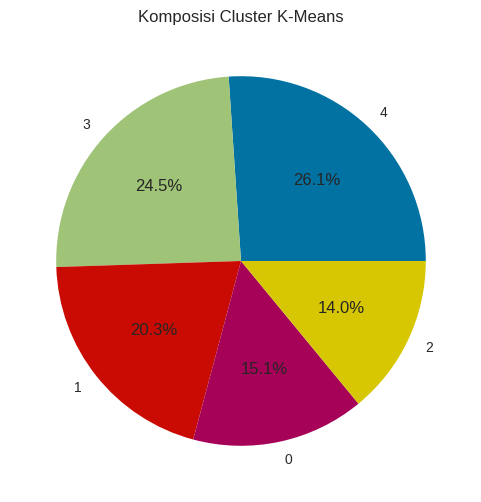

In [47]:
import matplotlib.pyplot as plt

# hitung jumlah data tiap cluster
cluster_counts = df_clean['cluster'].value_counts()

# pie chart
plt.figure(figsize=(6,6))
plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%'
)

plt.title('Komposisi Cluster K-Means')
plt.show()

In [50]:
# Lihat rata-rata tiap cluster
df_clean.groupby('cluster')[
    [
        'TransactionAmount',
        'CustomerAge',
        'TransactionDuration',
        'AccountBalance'
    ]
].mean().round(2)

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
cluster,,,,
0,833.09,43.95,119.01,4425.60
1,219.60,44.78,99.46,10336.86
2,205.25,45.25,236.54,5231.58
3,198.03,25.89,97.74,1648.17
4,185.66,62.17,92.37,4622.22


# Insight Hasil Clustering Transaksi

Berdasarkan evaluasi menggunakan K-Means Clustering, jumlah cluster optimal diperoleh pada:

k=5

yang menunjukkan bahwa data transaksi terbagi menjadi lima kelompok utama dengan karakteristik perilaku transaksi yang berbeda.

## Ringkasan Karakteristik Cluster

| Cluster   | Karakteristik Utama                                | Interpretasi                                            |
| --------- | -------------------------------------------------- | ------------------------------------------------------- |
| Cluster 0 | Nilai transaksi tertinggi                          | High transaction customers dengan potensi risiko tinggi |
| Cluster 1 | Saldo rekening tertinggi                           | Wealthy stable customers dengan risiko rendah           |
| Cluster 2 | Durasi transaksi paling lama                       | Potensi aktivitas anomali atau transaksi kompleks       |
| Cluster 3 | Customer muda dengan saldo rendah                  | Low transaction activity customers                      |
| Cluster 4 | Customer berusia lebih tua dengan transaksi stabil | Conservative customers dengan risiko rendah             |

## Insight Utama

Hasil clustering menunjukkan bahwa perilaku transaksi pelanggan memiliki pola yang beragam. Cluster 0 dan Cluster 2 menjadi kelompok yang paling menarik untuk analisis fraud karena memiliki karakteristik transaksi yang tidak normal, seperti nominal transaksi yang sangat tinggi dan durasi transaksi yang lebih lama dibanding cluster lainnya.

Sementara itu, Cluster 1, Cluster 3, dan Cluster 4 menunjukkan pola transaksi yang relatif stabil dan cenderung memiliki risiko lebih rendah.

## Kesimpulan

Metode clustering berhasil mengidentifikasi segmentasi perilaku transaksi pelanggan dan membantu menemukan kelompok transaksi yang berpotensi memiliki risiko fraud atau aktivitas anomali. Hasil ini dapat digunakan sebagai dasar dalam pengembangan sistem fraud monitoring dan risk analysis.


In [50]:
# Membaca file CSV
df = pd.read_csv('Data_hasil_clustering_kmeans.csv')

# Menampilkan 5 data teratas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2486 entries, 0 to 2485
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2486 non-null   object 
 1   AccountID                2486 non-null   object 
 2   TransactionAmount        2486 non-null   float64
 3   PreviousTransactionDate  2486 non-null   object 
 4   TransactionType          2486 non-null   object 
 5   Location                 2486 non-null   object 
 6   DeviceID                 2486 non-null   object 
 7   IP Address               2486 non-null   object 
 8   MerchantID               2486 non-null   object 
 9   Channel                  2486 non-null   object 
 10  CustomerAge              2486 non-null   float64
 11  CustomerOccupation       2486 non-null   object 
 12  TransactionDuration      2486 non-null   float64
 13  LoginAttempts            2486 non-null   float64
 14  AccountBalance          